In [85]:
import pandas as pd

df = pd.read_csv("Loan_default.csv")  

df.head()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


df.shape
df.columns

### Step 1: Initial Data Inspection

What was done:
Loaded the dataset and inspected its structure, dimensions, and data types.

In [89]:
print(df["Default"].value_counts())
print("\nPercentage distribution:\n")
print(df["Default"].value_counts(normalize=True) * 100)

Default
0    225694
1     29653
Name: count, dtype: int64

Percentage distribution:

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


### Step 2: Checking Class Distribution

Checked distribution of target variable (Default).

Important to detect class imbalance.

Accuracy alone is not reliable if dataset is imbalanced.

In [92]:
df = df.drop(columns=["LoanID"])
print(df.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')


In [94]:
# Loan burden relative to income
df["LoanIncomeRatio"] = df["LoanAmount"] / df["Income"]

# Employment stability ratio
df["EmploymentIncomeRatio"] = df["MonthsEmployed"] / (df["Age"] + 1)

# Credit score bands
df["CreditScoreBand"] = pd.cut(
    df["CreditScore"],
    bins=[300,580,670,740,800,850],
    labels=["Poor","Fair","Good","VeryGood","Excellent"]
)

### STEP 3 — Remove ID Column
Why remove LoanID?

It is a unique identifier.

It contains no predictive pattern.

Can cause overfitting if kept.

In [97]:
X = df.drop("Default", axis=1)
y = df["Default"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (255347, 19)
Target shape: (255347,)


In [99]:
# Feature Engineering

# Loan burden relative to income
df["LoanIncomeRatio"] = df["LoanAmount"] / df["Income"]

# Loan term relative to income
df["LoanTermIncomeRatio"] = df["LoanTerm"] / (df["Income"] + 1)

# Employment stability
df["EmploymentLengthRatio"] = df["MonthsEmployed"] / (df["Age"] + 1)

# Credit score bands (risk categories)
df["CreditScoreBand"] = pd.cut(
    df["CreditScore"],
    bins=[300,580,670,740,800,850],
    labels=["Poor","Fair","Good","VeryGood","Excellent"]
)

### Feature Engineering

Additional financial indicators were created to capture borrower risk patterns.

LoanIncomeRatio: Measures loan burden relative to borrower income.

LoanTermIncomeRatio: Captures how long the loan term is relative to income.

EmploymentLengthRatio: Indicates employment stability.

CreditScoreBand: Groups credit scores into risk categories.

These engineered features help the model better understand borrower financial risk.

### Step 4: Separating Features and Target

Split dataset into input features (X) and target variable (y).

Prevents accidental preprocessing of target column.

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class distribution same
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nTrain default %:\n", y_train.value_counts(normalize=True)*100)
print("\nTest default %:\n", y_test.value_counts(normalize=True)*100)

X_train: (204277, 19)
X_test: (51070, 19)

Train default %:
 Default
0    88.387337
1    11.612663
Name: proportion, dtype: float64

Test default %:
 Default
0    88.386528
1    11.613472
Name: proportion, dtype: float64


### Step 5: Train-Test Split

Split data into 80% training and 20% testing.

Used stratified sampling to maintain class distribution.

Prevents data leakage.

In [106]:
# Identify feature types again after feature engineering

cat_cols = X_train.select_dtypes(include=["object","category"]).columns
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns

print("Categorical Columns:\n", cat_cols)
print("\nNumerical Columns:\n", num_cols)

Categorical Columns:
 Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner', 'CreditScoreBand'],
      dtype='object')

Numerical Columns:
 Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
       'LoanIncomeRatio', 'EmploymentIncomeRatio'],
      dtype='object')


### Step 6: Identify Feature Types

Separated categorical and numerical features.

Required for proper encoding and scaling.

Done on training data to avoid leakage.

In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define transformers
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data (no fitting here!)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape:", X_test_processed.shape)

Processed Train Shape: (204277, 31)
Processed Test Shape: (51070, 31)


In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_processed, y_train)

# Predictions
y_pred = log_model.predict(X_test_processed)
y_prob = log_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.07      0.12      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070

ROC-AUC Score: 0.7616144632980271


### Step 8: Logistic Regression Model

Trained baseline logistic regression model.

Evaluated using precision, recall, F1-score, and ROC-AUC.

Used predicted probabilities for AUC calculation.

In [114]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[44878   261]
 [ 5519   412]]


In [116]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.3
y_pred_adjusted = (y_prob >= threshold).astype(int)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_adjusted))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_adjusted))

Confusion Matrix:

[[43208  1931]
 [ 4466  1465]]

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.96      0.93     45139
           1       0.43      0.25      0.31      5931

    accuracy                           0.87     51070
   macro avg       0.67      0.60      0.62     51070
weighted avg       0.85      0.87      0.86     51070



In [118]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_processed, y_train)

y_pred_tree = tree_model.predict(X_test_processed)
y_prob_tree = tree_model.predict_proba(X_test_processed)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report:\n")
print(classification_report(y_test, y_pred_tree))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_tree))

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45139
           1       0.19      0.22      0.21      5931

    accuracy                           0.80     51070
   macro avg       0.54      0.55      0.55     51070
weighted avg       0.81      0.80      0.81     51070

ROC-AUC: 0.550465698585193


In [119]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Classification Report:

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.04      0.08      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070

ROC-AUC: 0.7341497455643942


In [120]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.3
y_pred_rf_adj = (y_prob_rf >= threshold).astype(int)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf_adj))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_adj))

Confusion Matrix:

[[42637  2502]
 [ 4414  1517]]

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92     45139
           1       0.38      0.26      0.30      5931

    accuracy                           0.86     51070
   macro avg       0.64      0.60      0.61     51070
weighted avg       0.84      0.86      0.85     51070



In [121]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

C:\Users\aksha\New_folder\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:29:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.59      0.07      0.12      5931

    accuracy                           0.89     51070
   macro avg       0.74      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070

ROC-AUC: 0.7569307461006684


In [122]:
import numpy as np

neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_pos_weight = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("scale_pos_weight:", scale_pos_weight)


Negative: 180555
Positive: 23722
scale_pos_weight: 7.61128909872692


### Step 9: Handling Class Imbalance in XGBoost

Dataset is imbalanced (≈ 7.6:1 ratio of non-default to default).

Computed scale_pos_weight = 7.61.

This parameter increases penalty for misclassifying default cases.

Helps model focus more on minority class.

In [124]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_weighted = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_weighted.fit(X_train_processed, y_train)

y_pred_xgb_w = xgb_weighted.predict(X_test_processed)
y_prob_xgb_w = xgb_weighted.predict_proba(X_test_processed)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_w))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_w))

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.71      0.81     45139
           1       0.23      0.67      0.35      5931

    accuracy                           0.71     51070
   macro avg       0.59      0.69      0.58     51070
weighted avg       0.86      0.71      0.76     51070

ROC-AUC: 0.7569294126149815


### Step 10: XGBoost with Class Weighting

Applied scale_pos_weight = 7.61 to handle imbalance.

Recall for default class improved significantly (7% → 67%).

Precision decreased due to higher false positives.

Demonstrates impact of cost-sensitive learning.

In [127]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.7529584649430077


### Step 11: Hyperparameter Tuning with GridSearchCV

Performed hyperparameter tuning for XGBoost using GridSearchCV.

Used 3-fold cross-validation to evaluate parameter combinations.

Optimized model performance using ROC-AUC score due to class imbalance.

Identified the best configuration of depth, learning rate, and number of trees.

In [129]:
best_params = grid_search.best_params_

xgb_final = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    **best_params
)

xgb_final.fit(X_train_processed, y_train)

y_pred_final = xgb_final.predict(X_test_processed)
y_prob_final = xgb_final.predict_proba(X_test_processed)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))

Confusion Matrix:
 [[31403 13736]
 [ 1851  4080]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.70      0.80     45139
           1       0.23      0.69      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070

ROC-AUC: 0.7595257764818986


### Step 12: Final Tuned XGBoost Model

Trained XGBoost using best hyperparameters from GridSearchCV.

Model evaluated on test dataset.

Achieved ROC-AUC ≈ 0.758, highest among tested models.

Recall for default class improved significantly (~69%), meaning the model successfully detects most risky borrowers.

In [137]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    
    preds = (y_prob_final >= t).astype(int)
    
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results.append((t, precision, recall, f1))

import pandas as pd

threshold_df = pd.DataFrame(results, columns=["Threshold","Precision","Recall","F1"])

print(threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.118979  0.995785  0.212561
1        0.15   0.125407  0.987692  0.222556
2        0.20   0.133910  0.968302  0.235282
3        0.25   0.144528  0.941662  0.250595
4        0.30   0.156581  0.903052  0.266886
5        0.35   0.172259  0.862924  0.287189
6        0.40   0.190167  0.815883  0.308442
7        0.45   0.208275  0.755353  0.326519
8        0.50   0.229008  0.687911  0.343622
9        0.55   0.254445  0.615242  0.360004
10       0.60   0.284145  0.540887  0.372568
11       0.65   0.319194  0.454224  0.374922
12       0.70   0.355522  0.356601  0.356061
13       0.75   0.409432  0.266397  0.322778
14       0.80   0.483176  0.181588  0.263971
15       0.85   0.566000  0.095431  0.163324


In [139]:
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]

print("Best Threshold:")
print(best_row)

Best Threshold:
Threshold    0.650000
Precision    0.319194
Recall       0.454224
F1           0.374922
Name: 11, dtype: float64


In [141]:
best_threshold = 0.65

y_pred_final_tuned = (y_prob_final >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final_tuned))

Confusion Matrix:
 [[39393  5746]
 [ 3237  2694]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.87      0.90     45139
           1       0.32      0.45      0.37      5931

    accuracy                           0.82     51070
   macro avg       0.62      0.66      0.64     51070
weighted avg       0.85      0.82      0.84     51070



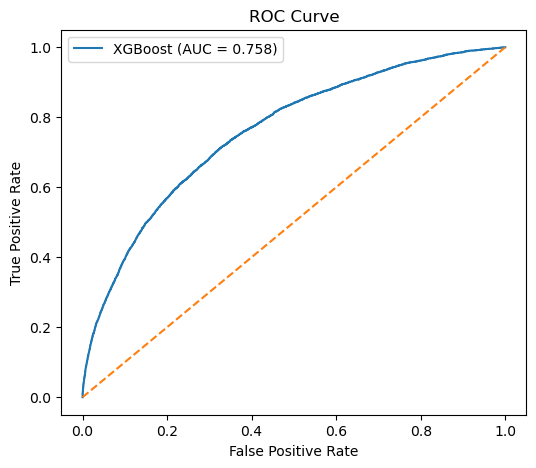

In [131]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="XGBoost (AUC = 0.758)")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve

Plotted the ROC curve to evaluate model discrimination ability.

ROC curve illustrates the trade-off between true positive rate and false positive rate.

Area under the curve (AUC) summarizes overall model performance.

                           Feature  Importance
0                         num__Age    0.183645
9             num__LoanIncomeRatio    0.107564
6                num__InterestRate    0.098749
4              num__MonthsEmployed    0.060531
25            cat__HasCoSigner_Yes    0.043224
20          cat__HasDependents_Yes    0.042294
16  cat__EmploymentType_Unemployed    0.036431
5              num__NumCreditLines    0.028489
17      cat__MaritalStatus_Married    0.028201
11      cat__Education_High School    0.028153


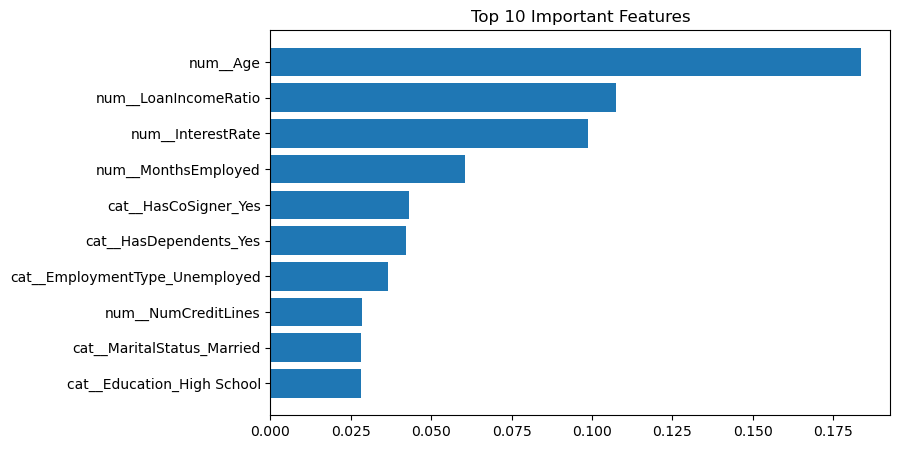

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

importances = xgb_final.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(10))

plt.figure(figsize=(8,5))
plt.barh(feat_imp["Feature"][:10], feat_imp["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

### Step 14: Feature Importance Analysis

Extracted feature importance from the trained XGBoost model.

Identified the most influential features affecting loan default prediction.

Helps interpret model decisions and understand key risk factors.

In [143]:
import joblib

# save model
joblib.dump(xgb_final, "loan_default_model.pkl")

# save preprocessing pipeline
joblib.dump(preprocessor, "preprocessor.pkl")

# save threshold
joblib.dump(best_threshold, "threshold.pkl")

print("Model, preprocessor, and threshold saved successfully.")

Model, preprocessor, and threshold saved successfully.
